# Analiza zbioru danych

Podsumowanie liczby plików i unikalnych nagrań na podstawie archiwów `train.7z` i `test.7z`.

## Konfiguracja

Importy, ścieżki do archiwów oraz lista klas docelowych.

In [15]:
from collections import defaultdict
from pathlib import Path
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio

DATA_DIR = Path("data")
TRAIN_ARCHIVE = DATA_DIR / "train.7z"
TEST_ARCHIVE = DATA_DIR / "test.7z"

IGNORED_CLASSES = {"_background_noise_"}
TARGET_LABEL_ORDER = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
TARGET_LABELS = set(TARGET_LABEL_ORDER)

## Odczyt archiwów

Funkcje pomocnicze do czytania listy plików i plików tekstowych bez rozpakowywania całego zbioru.

In [16]:
def archive_files(archive: Path) -> list[Path]:
    result = subprocess.run(
        ["7z", "l", "-slt", str(archive)],
        check=True,
        capture_output=True,
        text=True,
    )

    files = []
    entry = {}

    def add_file() -> None:
        if entry.get("Path") and "Size" in entry and not entry.get("Attributes", "").startswith("D"):
            files.append(Path(entry["Path"]))

    for line in result.stdout.splitlines():
        if not line:
            add_file()
            entry = {}
            continue

        if " = " in line:
            key, value = line.split(" = ", 1)
            entry[key] = value

    add_file()
    return files


def speaker_id(path: Path) -> str:
    return path.name.split("_nohash_", 1)[0]

In [17]:
def archive_lines(archive: Path, file_name: str) -> set[Path]:
    result = subprocess.run(
        ["7z", "e", "-so", str(archive), file_name],
        check=True,
        capture_output=True,
        text=True,
    )

    return {Path(line) for line in result.stdout.splitlines() if line}

In [18]:
def train_class(path: Path) -> str | None:
    parts = path.parts
    if len(parts) != 4 or parts[:2] != ("train", "audio") or path.suffix != ".wav":
        return None

    label = parts[2]
    return None if label in IGNORED_CLASSES else label


def test_audio_file(path: Path) -> bool:
    return len(path.parts) == 3 and path.parts[:2] == ("test", "audio") and path.suffix == ".wav"


def dataset_summary(paths: list[Path]) -> pd.DataFrame:
    files_by_class = defaultdict(list)

    for path in paths:
        label = train_class(path)
        if label:
            files_by_class[label].append(path)

    rows = [
        {
            "class": label,
            "total_count": len(files),
            "unique_count": len({speaker_id(path) for path in files}),
        }
        for label, files in files_by_class.items()
    ]

    return pd.DataFrame(rows, columns=["class", "total_count", "unique_count"]).sort_values(
        "class", ignore_index=True
    )

## Liczebność klas

Podsumowanie liczby nagrań oraz unikalnych identyfikatorów mówców dla klas w `train.7z`.

In [19]:
train_files = archive_files(TRAIN_ARCHIVE)
test_files = [path for path in archive_files(TEST_ARCHIVE) if test_audio_file(path)]

df = dataset_summary(train_files)
df

,class,total_count,unique_count
0,bed,1713,1177
1,bird,1731,1194
2,cat,1733,1180
3,dog,1746,1209
4,down,2359,1206
5,eight,2352,1179
6,five,2357,1181
7,four,2372,1194
8,go,2372,1182
9,happy,1742,1178


In [20]:
print(f"Total number of train files: {int(df['total_count'].sum())}")
print(f"Total number of test files: {len(test_files)}")

Total number of train files: 64721
Total number of test files: 158538


In [21]:
def plot_counts(data: pd.DataFrame, title: str) -> None:
    if data.empty:
        print("No files found to plot.")
        return

    data.plot(x="class", y=["total_count", "unique_count"], kind="bar", figsize=(15, 7))
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Count Type")
    plt.tight_layout()
    plt.show()

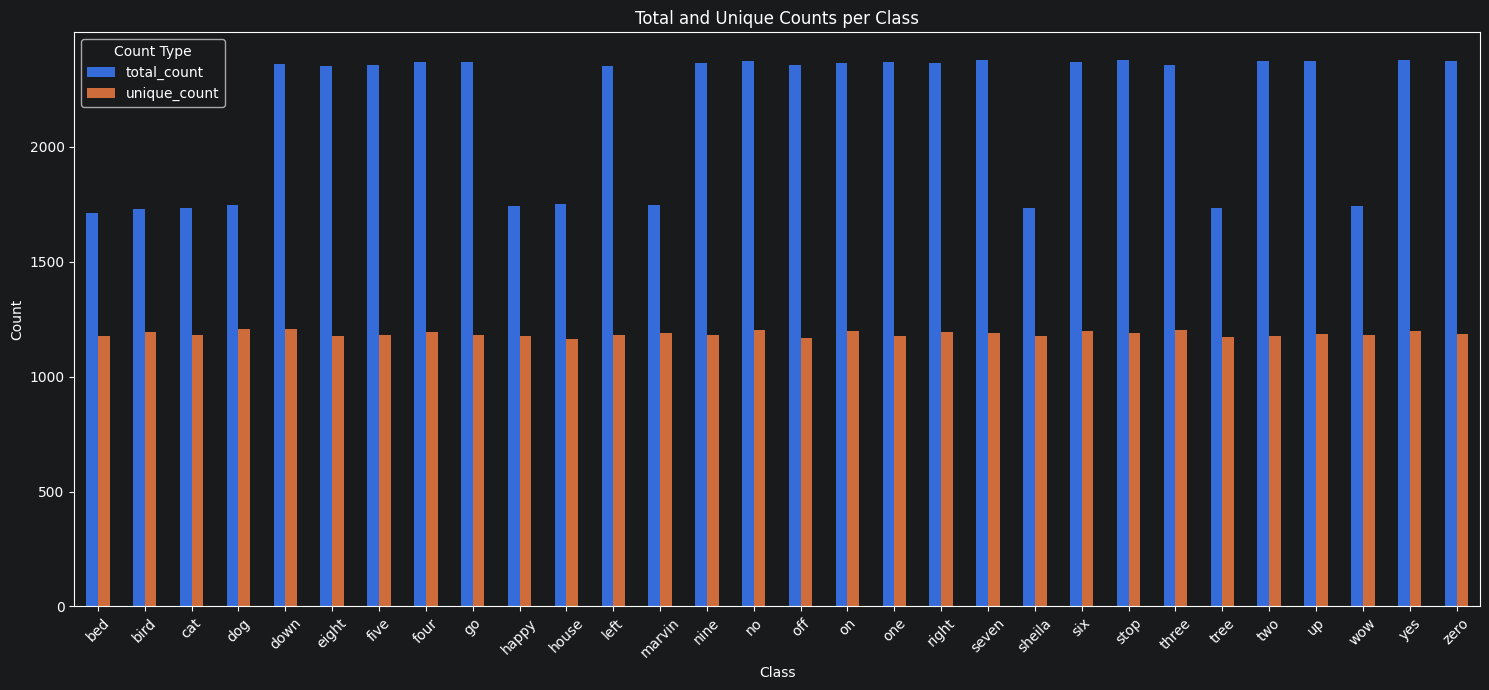

In [22]:
plot_counts(df, "Total and Unique Counts per Class")

## Udział klas

Procentowy udział klas w zbiorze treningowym, przydatny do oceny balansu danych.

In [23]:
class_balance = df.assign(
    share_percent=lambda data: (100 * data["total_count"] / data["total_count"].sum()).round(2)
)

class_balance

,class,total_count,unique_count,share_percent
0,bed,1713,1177,2.65
1,bird,1731,1194,2.67
2,cat,1733,1180,2.68
3,dog,1746,1209,2.70
4,down,2359,1206,3.64
5,eight,2352,1179,3.63
6,five,2357,1181,3.64
7,four,2372,1194,3.66
8,go,2372,1182,3.66
9,happy,1742,1178,2.69


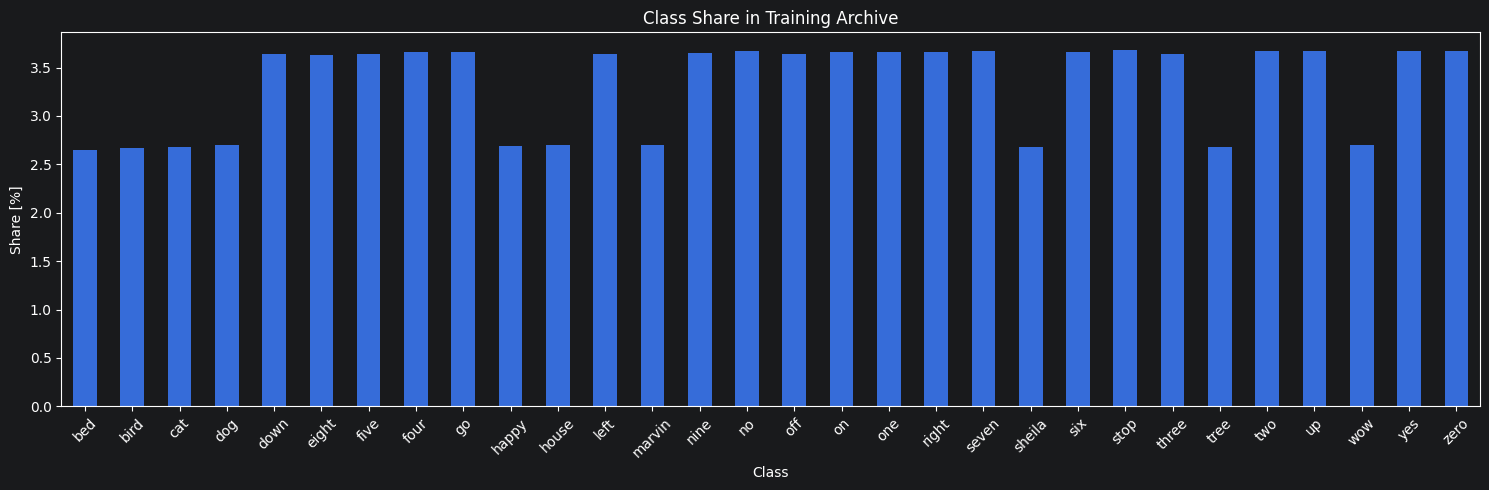

In [24]:
class_balance.plot(x="class", y="share_percent", kind="bar", figsize=(15, 5), legend=False)
plt.title("Class Share in Training Archive")
plt.xlabel("Class")
plt.ylabel("Share [%]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Podział danych

Porównanie rozkładu klas między splitami `train`, `validation` i `testing` zapisanymi w archiwum.

In [25]:
validation_paths = archive_lines(TRAIN_ARCHIVE, "train/validation_list.txt")
testing_paths = archive_lines(TRAIN_ARCHIVE, "train/testing_list.txt")

rows = []

for path in train_files:
    label = train_class(path)
    if not label:
        continue

    relative_path = Path(*path.parts[2:])
    split = "validation" if relative_path in validation_paths else "testing" if relative_path in testing_paths else "train"
    rows.append({"class": label, "split": split})

split_data = pd.DataFrame(rows)
split_counts = pd.crosstab(split_data["class"], split_data["split"])
split_counts = split_counts.reindex(columns=["train", "validation", "testing"], fill_value=0)
split_counts["total"] = split_counts.sum(axis=1)

split_counts.reset_index()

split,class,train,validation,testing,total
0,bed,1340,197,176,1713
1,bird,1411,162,158,1731
2,cat,1399,168,166,1733
3,dog,1396,170,180,1746
4,down,1842,264,253,2359
5,eight,1852,243,257,2352
6,five,1844,242,271,2357
7,four,1839,280,253,2372
8,go,1861,260,251,2372
9,happy,1373,189,180,1742


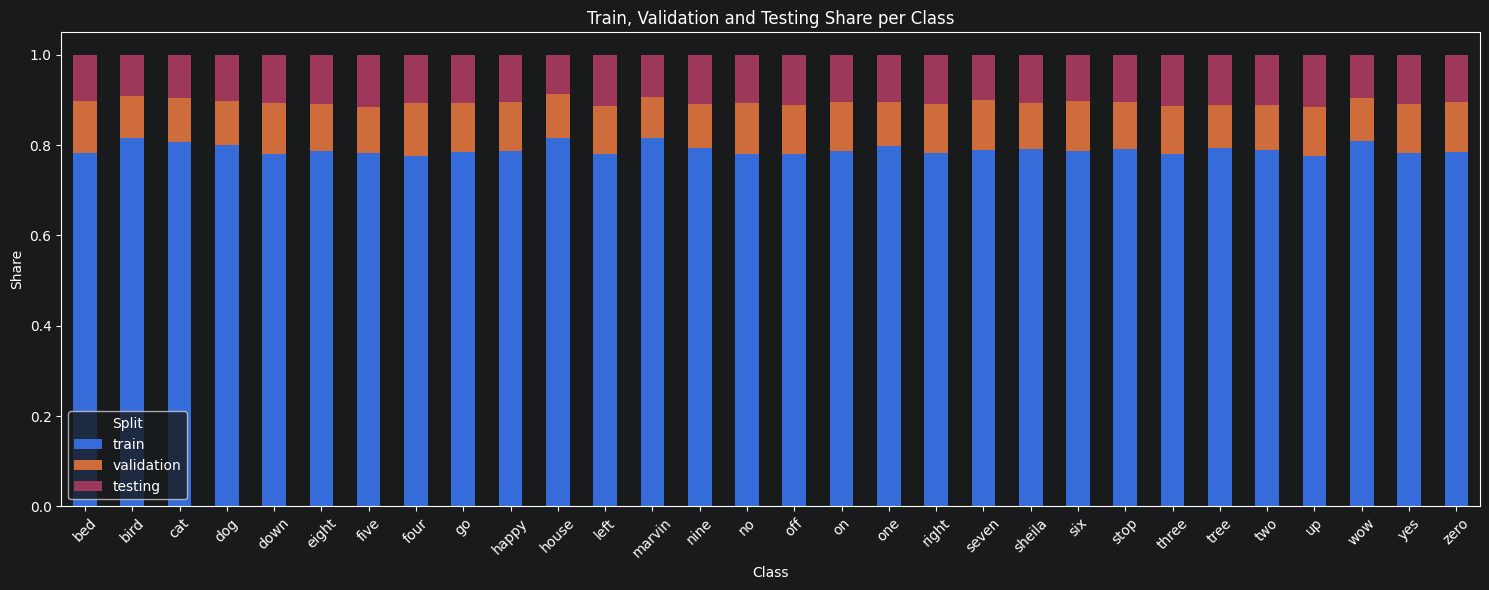

In [26]:
split_share = split_counts[["train", "validation", "testing"]].div(split_counts["total"], axis=0)

split_share.plot(kind="bar", stacked=True, figsize=(15, 6))
plt.title("Train, Validation and Testing Share per Class")
plt.xlabel("Class")
plt.ylabel("Share")
plt.xticks(rotation=45)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

## Klasy docelowe i unknown

Agregacja klas spoza listy komend docelowych do grupy `unknown`.

In [27]:
target_df = df[df["class"].isin(TARGET_LABELS)].copy()
unknown_counts = df.loc[~df["class"].isin(TARGET_LABELS), ["total_count", "unique_count"]].sum()

target_df = pd.concat(
    [
        target_df,
        pd.DataFrame(
            [
                {
                    "class": "unknown",
                    "total_count": int(unknown_counts["total_count"]),
                    "unique_count": int(unknown_counts["unique_count"]),
                }
            ]
        ),
    ],
    ignore_index=True,
).sort_values("class", ignore_index=True)

target_df

,class,total_count,unique_count
0,down,2359,1206
1,go,2372,1182
2,left,2353,1180
3,no,2375,1203
4,off,2357,1170
5,on,2367,1198
6,right,2367,1194
7,stop,2380,1191
8,unknown,41039,23693
9,up,2375,1186


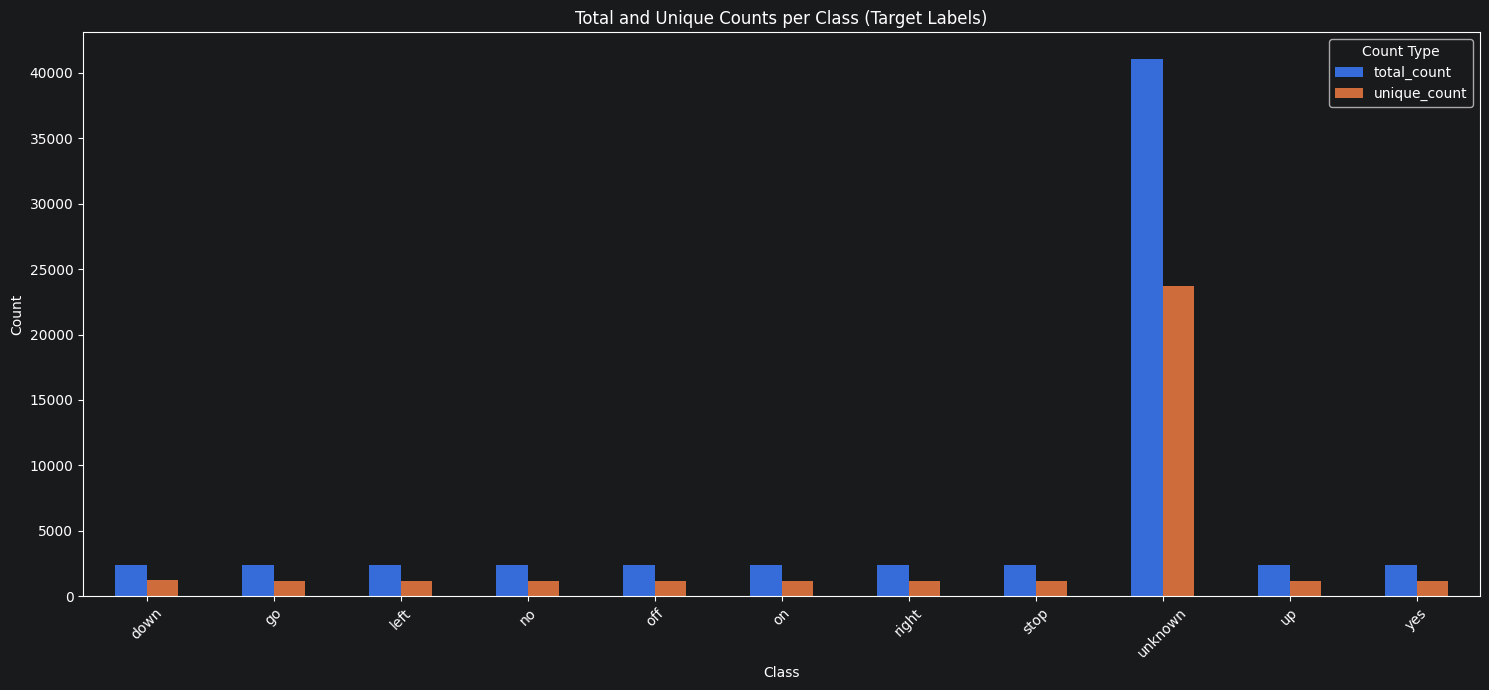

In [28]:
plot_counts(target_df, "Total and Unique Counts per Class (Target Labels)")

## Mel spectrogramy

Wizualizacja przykładowych oraz uśrednionych mel spectrogramów dla klas docelowych.

In [29]:
MEL_AVERAGE_SAMPLES_PER_CLASS = 8

target_audio_paths = {
    label: sorted(path for path in train_files if train_class(path) == label)
    for label in TARGET_LABEL_ORDER
}


def sample_paths(paths: list[Path], sample_count: int) -> list[Path]:
    if len(paths) <= sample_count:
        return paths

    positions = np.linspace(0, len(paths) - 1, sample_count, dtype=int)
    return [paths[position] for position in positions]


def unique_paths(paths: list[Path]) -> list[Path]:
    return list(dict.fromkeys(paths))


example_paths = [target_audio_paths[label][0] for label in TARGET_LABEL_ORDER]
average_paths = [
    path
    for label in TARGET_LABEL_ORDER
    for path in sample_paths(target_audio_paths[label], MEL_AVERAGE_SAMPLES_PER_CLASS)
]
mel_archive_paths = unique_paths(example_paths + average_paths)

In [30]:
def extract_archive_files(archive: Path, paths: list[Path], output_dir: Path) -> dict[Path, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    command = ["7z", "x", "-y", str(archive), f"-o{output_dir}"] + [str(path) for path in paths]
    subprocess.run(command, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return {path: output_dir / path for path in paths}


def load_audio(path: Path) -> tuple[torch.Tensor, int]:
    waveform, sample_rate = torchaudio.load(path)
    return waveform.mean(dim=0), sample_rate


def mel_spectrogram(audio: torch.Tensor, sample_rate: int) -> np.ndarray:
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=512,
        hop_length=160,
        n_mels=64,
        power=2.0,
    )
    to_db = torchaudio.transforms.AmplitudeToDB(stype="power")
    return to_db(transform(audio)).numpy()


def fixed_frame_count(mel: np.ndarray, frame_count: int = 101) -> np.ndarray:
    if mel.shape[1] >= frame_count:
        return mel[:, :frame_count]

    return np.pad(mel, ((0, 0), (0, frame_count - mel.shape[1])), mode="edge")

In [31]:
mel_cache = tempfile.TemporaryDirectory()
local_audio_paths = extract_archive_files(TRAIN_ARCHIVE, mel_archive_paths, Path(mel_cache.name))

print(f"Extracted {len(local_audio_paths)} audio files for mel spectrogram analysis.")

Extracted 80 audio files for mel spectrogram analysis.


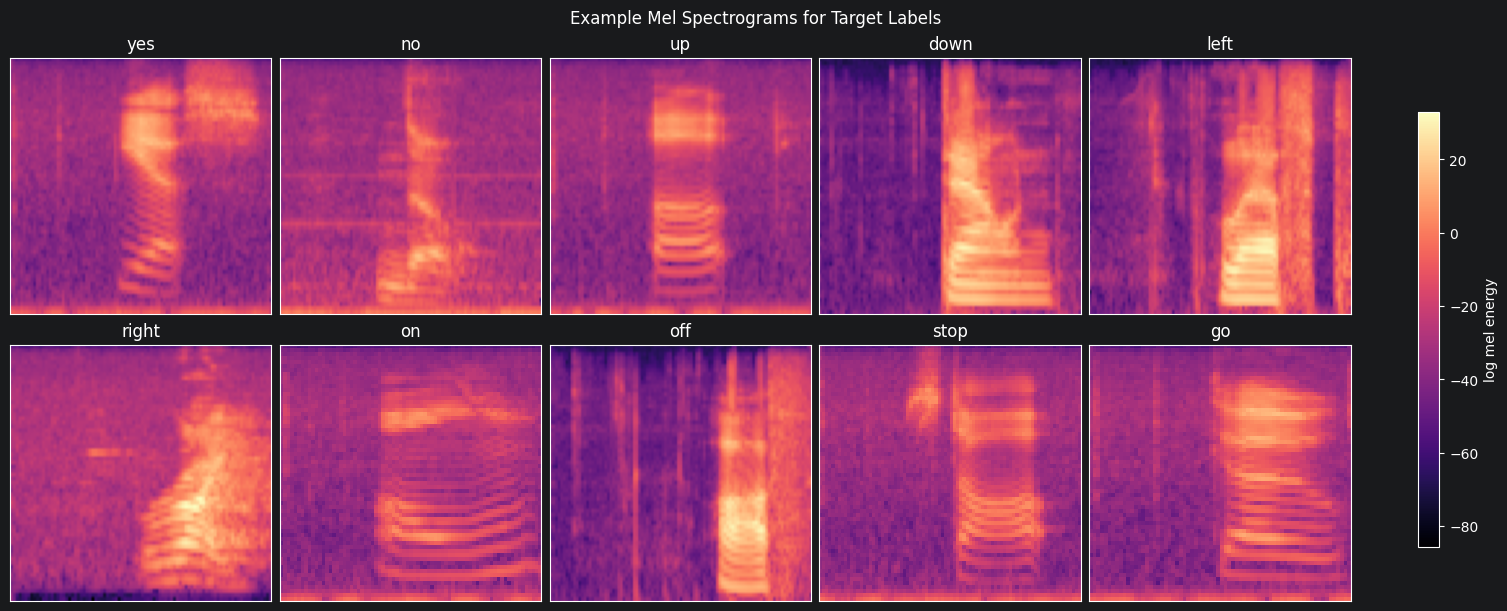

In [32]:
def plot_mel_grid(mels: dict[str, np.ndarray], title: str) -> None:
    values = list(mels.values())
    vmin = min(mel.min() for mel in values)
    vmax = max(mel.max() for mel in values)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), constrained_layout=True)
    for axis, label in zip(axes.flat, TARGET_LABEL_ORDER):
        image = axis.imshow(mels[label], origin="lower", aspect="auto", cmap="magma", vmin=vmin, vmax=vmax)
        axis.set_title(label)
        axis.set_xticks([])
        axis.set_yticks([])

    fig.colorbar(image, ax=axes, shrink=0.8, label="log mel energy")
    fig.suptitle(title)
    plt.show()


example_mels = {}
for label, path in zip(TARGET_LABEL_ORDER, example_paths):
    audio, sample_rate = load_audio(local_audio_paths[path])
    example_mels[label] = mel_spectrogram(audio, sample_rate)

plot_mel_grid(example_mels, "Example Mel Spectrograms for Target Labels")

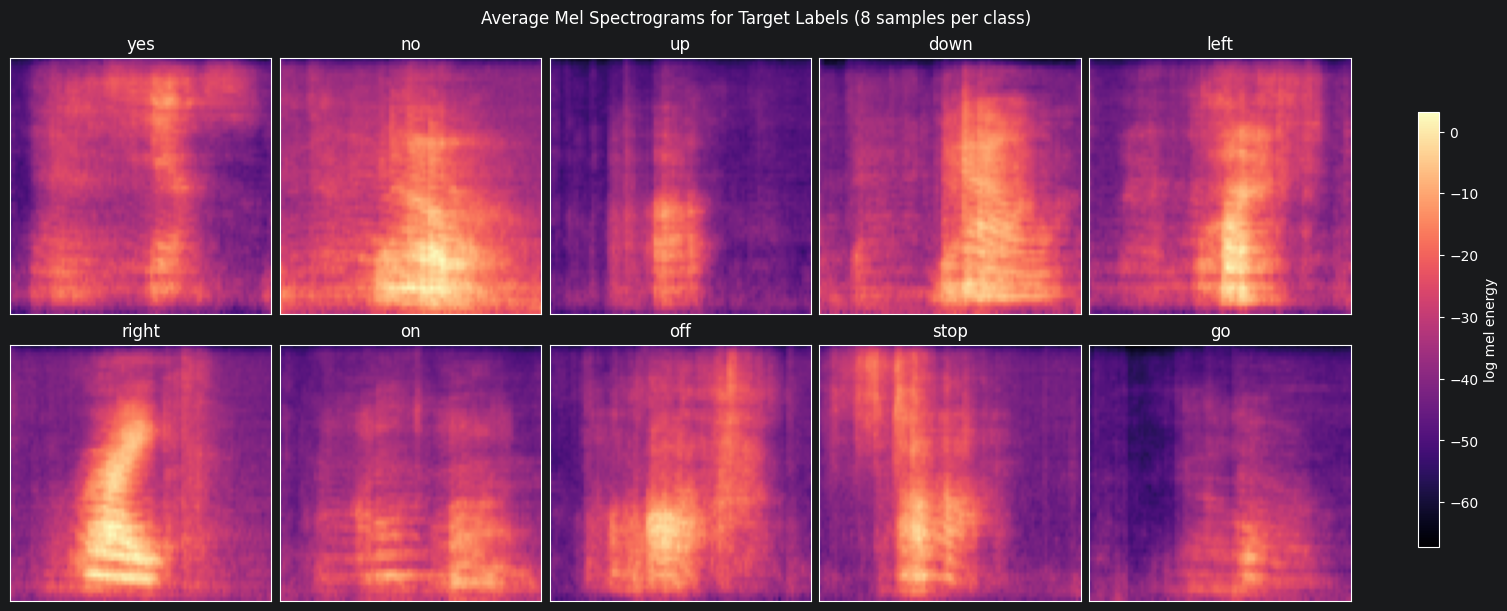

In [33]:
average_mels = {}

for label in TARGET_LABEL_ORDER:
    class_mels = []
    for path in sample_paths(target_audio_paths[label], MEL_AVERAGE_SAMPLES_PER_CLASS):
        audio, sample_rate = load_audio(local_audio_paths[path])
        class_mels.append(fixed_frame_count(mel_spectrogram(audio, sample_rate)))

    average_mels[label] = np.mean(class_mels, axis=0)

plot_mel_grid(
    average_mels,
    f"Average Mel Spectrograms for Target Labels ({MEL_AVERAGE_SAMPLES_PER_CLASS} samples per class)",
)